#Visualizing Neural Network Features
#### Objective: Understand what a Convolutional Neural Network (CNN) actually "sees" at different stages of processing.

#### Concept: When a Deep Learning model looks at an image, it processes it through layers.

- Early Layers: Act like the retina. They detect simple lines, edges, and color gradients.

- Middle Layers: Combine edges to find shapes, circles, and patterns.

- Deep Layers: Combine shapes to identify complex concepts like "eyes," "wheels," or "fur."

#### In this exercise, we will use PyTorch Hooks. A "hook" allows us to intercept the data flowing through the network while it is processing an image, so we can save it and visualize it.

####Instructions:

- Run the setup code to load the model.

- Run the visualization code.

- Compare Layer 1 (Lines) vs. Layer 4 (Abstract Blobs).

- Upload your own image to see how the network reacts to it.

In [ ]:
#@title Imports and Model Loading
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request
import os

# Check if we can use a GPU (Graphics Card), otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the ResNet18 model with pre-trained weights (trained on ImageNet)
# We set the model to 'eval' mode because we are not training it, only using it.
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.to(device)
model.eval()

print("Model loaded successfully.")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


Model loaded successfully.


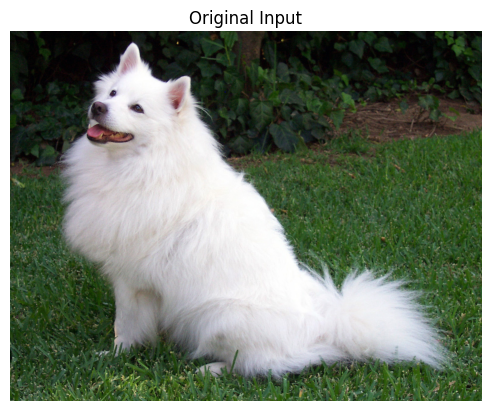

In [ ]:
#@title Image Processing
# Function to get an image from a URL
def get_image(url, filename):
    try:
        urllib.request.urlretrieve(url, filename)
    except:
        print("Error downloading.")
    return filename

# --- STUDENT PLAY ZONE: CHANGE THE URL BELOW ---
# Try finding a URL of a cat, a building, or a car.
image_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
filename = "input_image.jpg"
# -----------------------------------------------

get_image(image_url, filename)

# We need to process the image so the AI can read it (Resize and Normalize)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

raw_image = Image.open(filename)
input_tensor = preprocess(raw_image)
# The model expects a batch of images, so we add a dimension at the start (1, 3, 224, 224)
input_batch = input_tensor.unsqueeze(0).to(device)

# Show the original image
plt.imshow(raw_image)
plt.axis('off')
plt.title("Original Input")
plt.show()

In [ ]:
#@title Registering Hooks
# Dictionary to store the output of the layers
activations = {}

# This function creates the 'wiretap'
def get_activation(name):
    def hook(model, input, output):
        # We use .detach() to stop PyTorch from tracking gradients (saves memory)
        activations[name] = output.detach()
    return hook

# We attach hooks to 'layer1' (early) and 'layer4' (deep)
# You can inspect other layers by changing these names (e.g., layer2, layer3)
model.layer1.register_forward_hook(get_activation('layer1'))
model.layer4.register_forward_hook(get_activation('layer4'))

# Pass the image through the model
# The hooks will automatically capture data during this step
output = model(input_batch)

print("Forward pass complete. Features captured.")

Forward pass complete. Features captured.


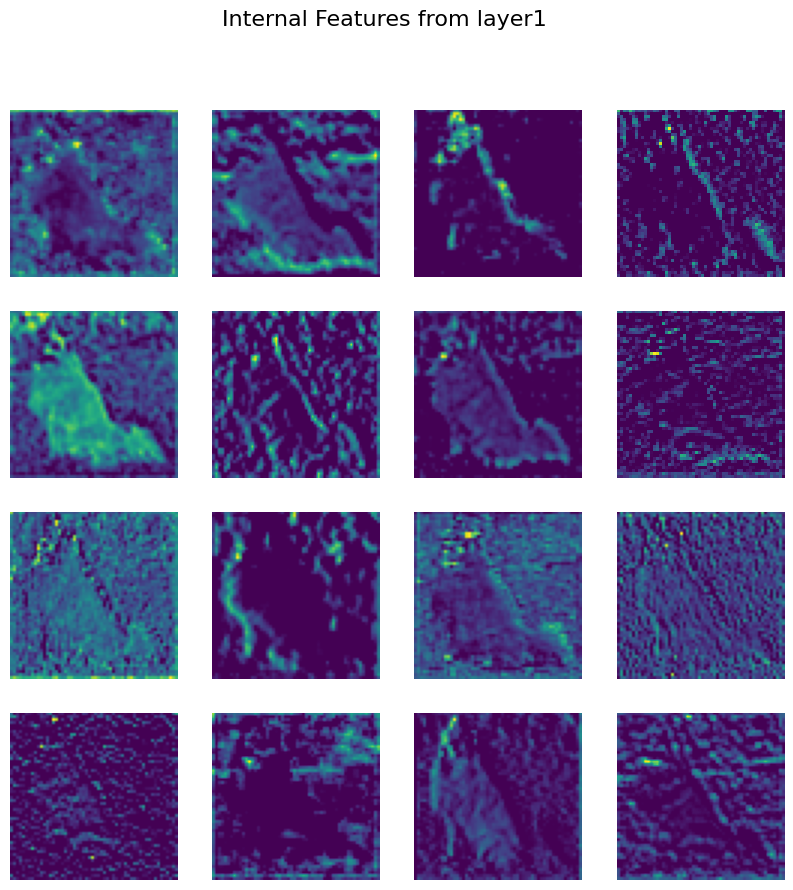

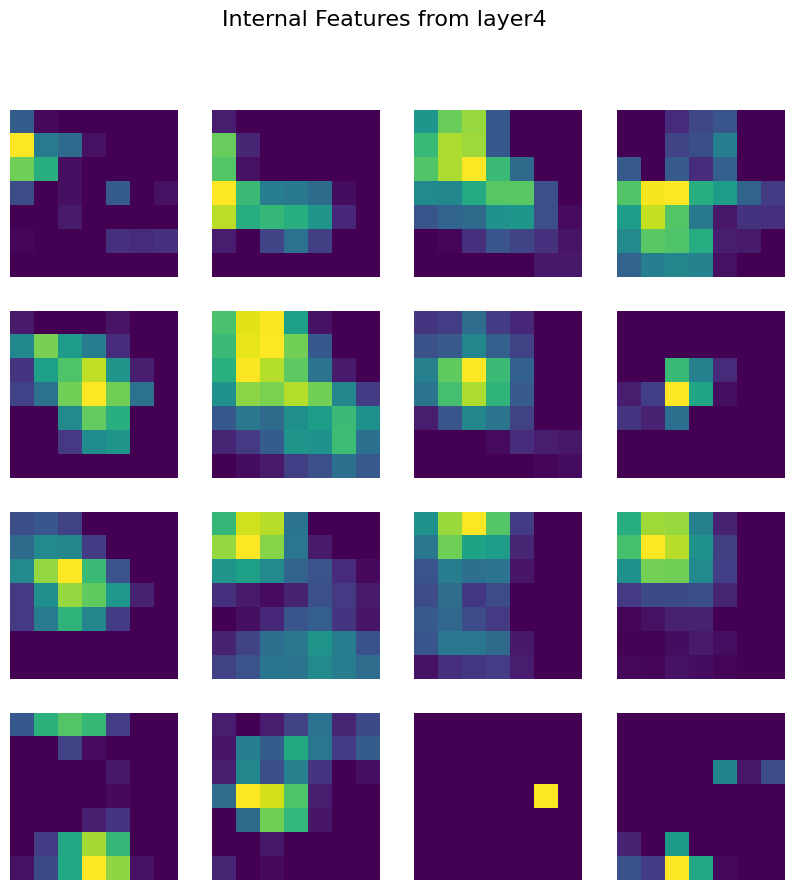

In [ ]:
#@title Visualization
def plot_activations(layer_name, num_channels=16):
    # Get the data for the requested layer
    if layer_name not in activations:
        print(f"Layer {layer_name} not found.")
        return

    # Remove the batch dimension
    act = activations[layer_name].squeeze()

    # Create a grid of plots (4x4)
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle(f"Internal Features from {layer_name}", fontsize=16)

    for i in range(num_channels):
        row = i // 4
        col = i % 4
        ax = axes[row, col]

        # Display the channel as a heatmap
        # .cpu() moves data from GPU to CPU for plotting
        ax.imshow(act[i].cpu(), cmap='viridis')
        ax.axis('off')
    plt.show()

# Visualize Layer 1: Look for simple lines, edges, and colors
plot_activations('layer1')

# Visualize Layer 4: Look for abstract blobs or specific object parts
plot_activations('layer4')